In [1]:
!pip install nltk wordcloud -q

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from wordcloud import WordCloud
import joblib

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jaina\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jaina\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jaina\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
train_path = "train_data.txt"
test_solution_path = "test_data_solution.txt"
test_path = "test_data.txt"

train_df = pd.read_csv(
    train_path,
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

test_solution_df = pd.read_csv(
    test_solution_path,
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

test_df = pd.read_csv(
    test_path,
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "TITLE", "DESCRIPTION"]
)

print("Train Shape:", train_df.shape)
print("Test Solution Shape:", test_solution_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (54214, 4)
Test Solution Shape: (54200, 4)
Test Shape: (54200, 3)


In [11]:
train_df.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [13]:
print(train_df.isnull().sum())
print(test_solution_df.isnull().sum())

ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64
ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64


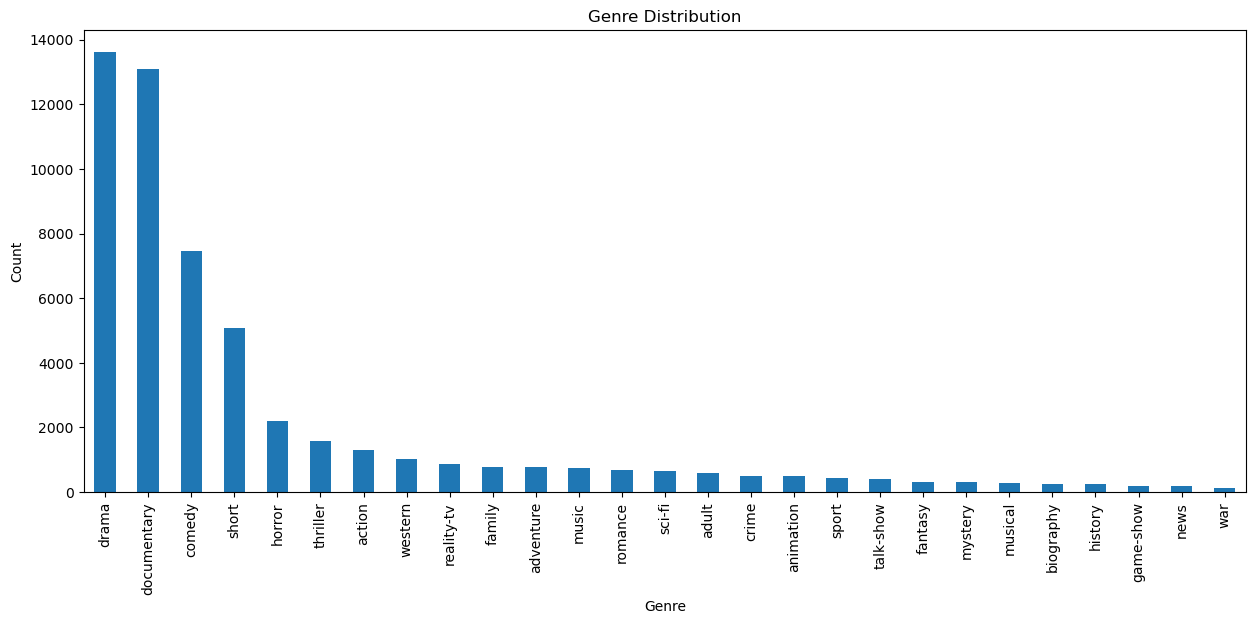

In [15]:
plt.figure(figsize=(15,6))

train_df["GENRE"].value_counts().plot(kind='bar')

plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

In [17]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
train_df["clean_text"] = train_df["DESCRIPTION"].apply(clean_text)

test_solution_df["clean_text"] = (
    test_solution_df["DESCRIPTION"]
    .apply(clean_text)
)

test_df["clean_text"] = (
    test_df["DESCRIPTION"]
    .apply(clean_text)
)

print("Preprocessing Completed")

Preprocessing Completed


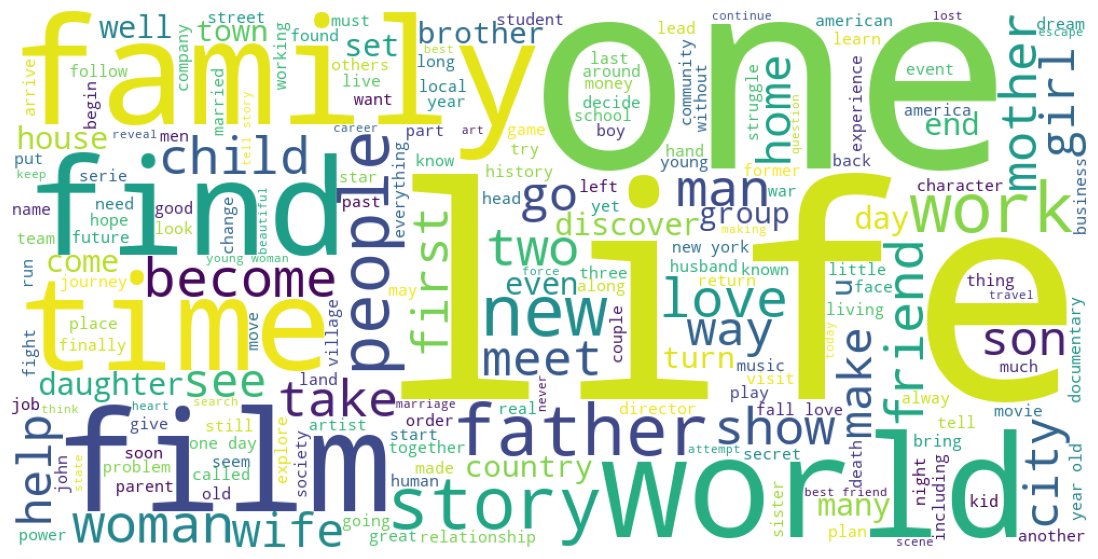

In [21]:
all_words = " ".join(train_df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [23]:
X_train = train_df["clean_text"]
y_train = train_df["GENRE"]

X_test = test_solution_df["clean_text"]
y_test = test_solution_df["GENRE"]

In [25]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

In [27]:
nb_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier", MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)

nb_pred = nb_pipeline.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.5071955719557195


In [29]:
lr_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier",
     LogisticRegression(
         max_iter=2000,
         class_weight='balanced'
     ))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.4900738007380074


In [31]:
svm_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier", LinearSVC())
])

svm_pipeline.fit(X_train, y_train)

svm_pred = svm_pipeline.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.5755166051660516


                 Model  Accuracy
0          Naive Bayes  0.507196
1  Logistic Regression  0.490074
2                  SVM  0.575517


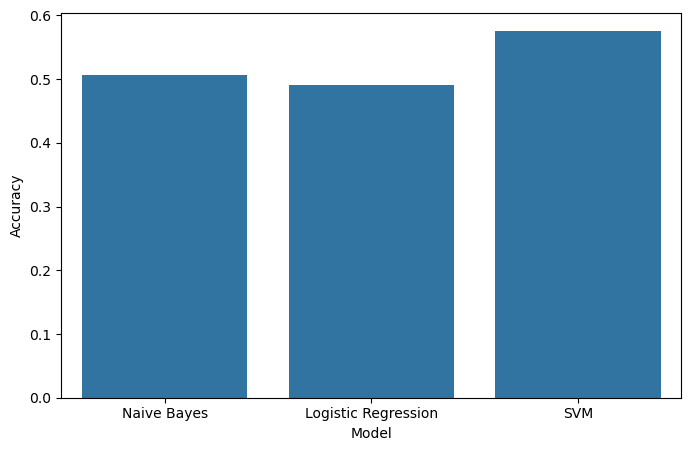

In [33]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.show()

In [35]:
lr_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier", LogisticRegression())
])

param_grid = {
    'classifier__C': [1, 3, 5],
    'classifier__max_iter': [2000],
    'classifier__class_weight': ['balanced']
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:")
print(grid_lr.best_params_)

print("Best CV Score:")
print(grid_lr.best_score_)

Best Parameters:
{'classifier__C': 5, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 2000}
Best CV Score:
0.5505958088750432


In [38]:
svm_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier", LinearSVC())
])

param_grid = {
    'classifier__C': [0.5, 1, 1.5, 2]
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("Best CV Score:")
print(grid_svm.best_score_)

Best Parameters:
{'classifier__C': 0.5}
Best CV Score:
0.5871730992193197


In [42]:
best_model = grid_svm.best_estimator_

predictions = best_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.5909225092250923


In [44]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

      action       0.45      0.34      0.39      1314
       adult       0.66      0.41      0.51       590
   adventure       0.56      0.22      0.32       775
   animation       0.37      0.12      0.18       498
   biography       0.00      0.00      0.00       264
      comedy       0.55      0.59      0.57      7446
       crime       0.26      0.05      0.09       505
 documentary       0.69      0.84      0.75     13096
       drama       0.57      0.73      0.64     13612
      family       0.38      0.12      0.18       783
     fantasy       0.45      0.11      0.17       322
   game-show       0.83      0.65      0.73       193
     history       0.33      0.01      0.02       243
      horror       0.62      0.64      0.63      2204
       music       0.63      0.52      0.57       731
     musical       0.30      0.05      0.09       276
     mystery       0.24      0.02      0.04       318
        news       0.65    

In [46]:
f1 = f1_score(
    y_test,
    predictions,
    average='weighted'
)

print("Weighted F1 Score:", f1)

Weighted F1 Score: 0.5612840366211932


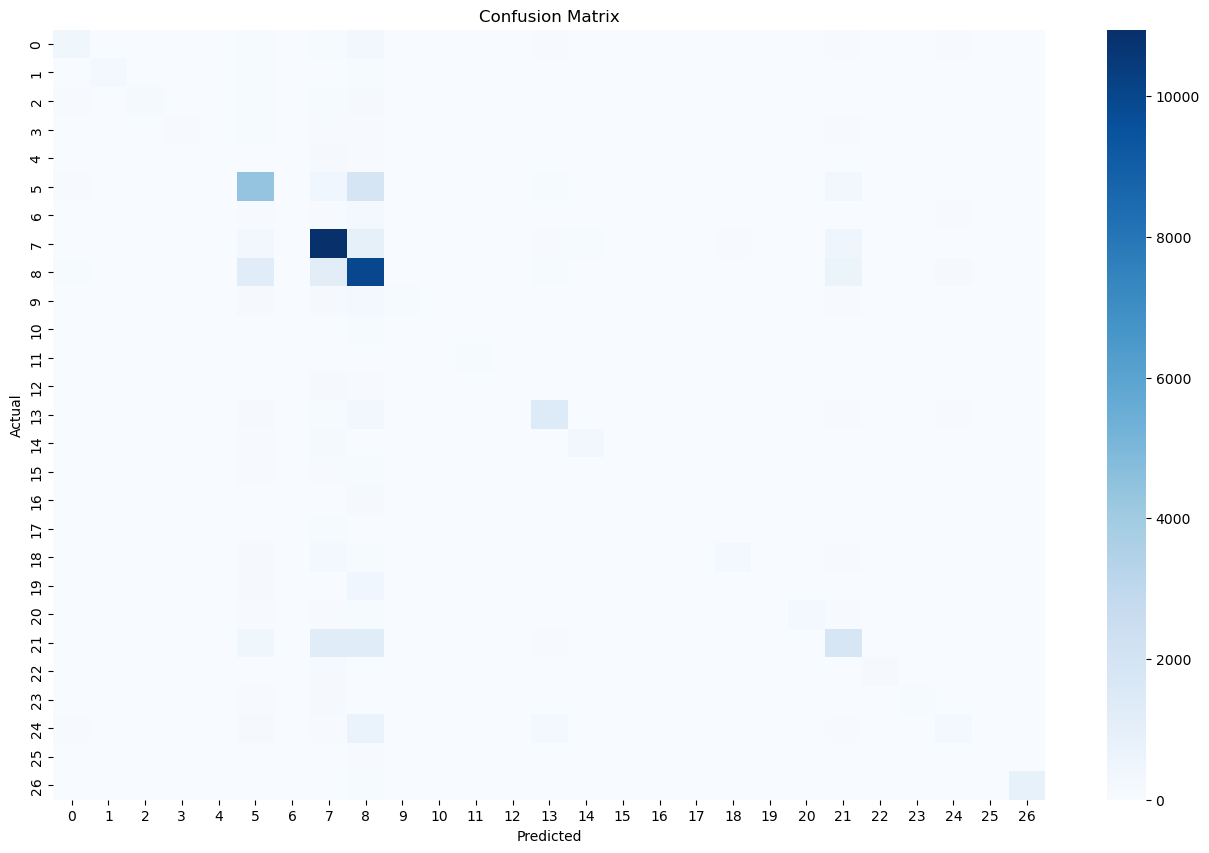

In [48]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(16,10))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Score:",
      cv_scores.mean())

Cross Validation Scores:
[0.59347044 0.58572351 0.58756802 0.59153371 0.59287954]
Average CV Score: 0.5902350434297247


In [52]:
test_predictions = best_model.predict(
    test_df["clean_text"]
)

test_df["Predicted_Genre"] = (
    test_predictions
)

test_df.head()

,ID,TITLE,DESCRIPTION,clean_text,Predicted_Genre
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apart...",lr brane love life car apartment job especiall...,comedy
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty chi...",spain march quico naughty child three belongin...,drama
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family o...,one year life albin family shepherd north tran...,documentary
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with his...",father died hasnt spoken brother year serious ...,drama
4,5,Er nu zhai (1955),Before he was known internationally as a marti...,known internationally martial art superstar br...,drama


In [66]:
movie_plot = """
A shy musician falls deeply in love with a
fashion designer, and together they navigate
heartbreak, relationships, and unexpected
romantic moments in Paris.
"""
prediction = best_model.predict(
    [movie_plot]
)

print("Predicted Genre:",
      prediction[0])

Predicted Genre: romance


In [68]:
joblib.dump(
    best_model,
    "movie_genre_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
